<a href="https://colab.research.google.com/github/ChristysTechLab/medical-insurance-cost-analysis/blob/main/medical_insurance_cost_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Medical Insurance Cost Analysis

## Project Overview

This project explores factors that may influence medical insurance charges using exploratory data analysis (EDA). The analysis examines relationships between insurance costs and variables such as age, BMI, smoking status, number of children, and geographic region.

The goal is to identify patterns and trends within the dataset using Python, pandas, and data visualization techniques.

## Data Import and Loading

The required libraries were imported, and the Medical Cost Personal Dataset was loaded into a Pandas DataFrame for analysis. The first five rows were displayed to verify that the dataset loaded successfully.

In [52]:
import pandas as pd

df = pd.read_csv("insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Data Overview and Quality Check

The dataset structure, data types, and completeness were reviewed before beginning the analysis.

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [54]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Summary Statistics

Descriptive statistics were calculated for the numerical variables in the dataset.

Key observations:

- The average age of individuals is approximately 39 years.
- The average insurance charge is approximately $13,270.
- Insurance charges vary considerably across individuals, indicating a wide distribution of medical costs.

# Exploratory Data Analysis (EDA)

Exploratory data analysis was performed to identify patterns and relationships between insurance charges and the variables contained in the dataset.

In [55]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [56]:
df["smoker"].value_counts()

,count
smoker,
no,1064
yes,274


In [57]:
df["region"].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


In [58]:
df.groupby("smoker")["charges"].mean()

,charges
smoker,
no,8434.268298
yes,32050.231832


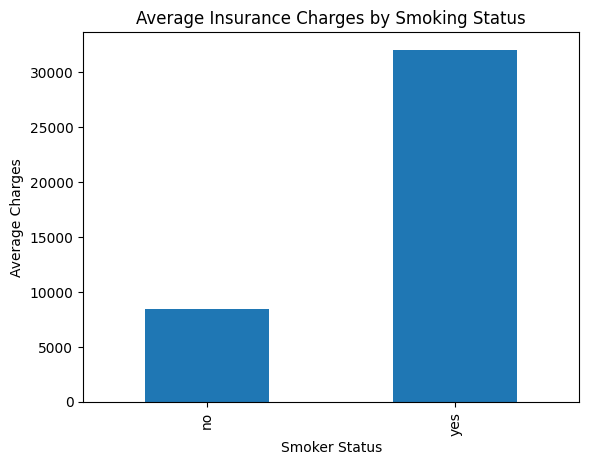

In [59]:
import matplotlib.pyplot as plt

df.groupby("smoker")["charges"].mean().plot(kind="bar")

plt.title("Average Insurance Charges by Smoking Status")
plt.xlabel("Smoker Status")
plt.ylabel("Average Charges")

plt.show()

## Smoking Status Analysis

This section compares average insurance charges between smokers and non-smokers.

In [60]:
df.groupby("smoker")["charges"].mean().to_string()

'smoker\nno      8434.268298\nyes    32050.231832'

### Observation

Smokers have substantially higher average insurance charges than non-smokers.

### Average Insurance Charges by Smoking Status

The average insurance charges for smokers and non-smokers are visualized using a bar chart.

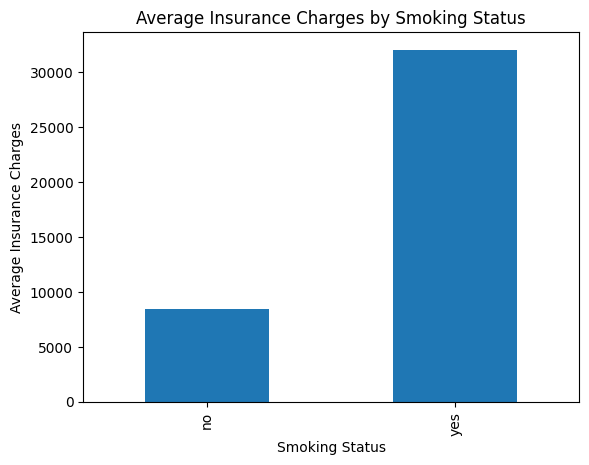

In [61]:
import matplotlib.pyplot as plt

df.groupby("smoker")["charges"].mean().plot(kind="bar")

plt.title("Average Insurance Charges by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Average Insurance Charges")

plt.show()

### Insight

The bar chart shows that smokers have significantly higher average insurance charges than non-smokers. This suggests that smoking is one of the strongest factors associated with increased medical costs.

### Distribution of Insurance Charges by Smoking Status

A box plot was created to compare the distribution of insurance charges between smokers and non-smokers.

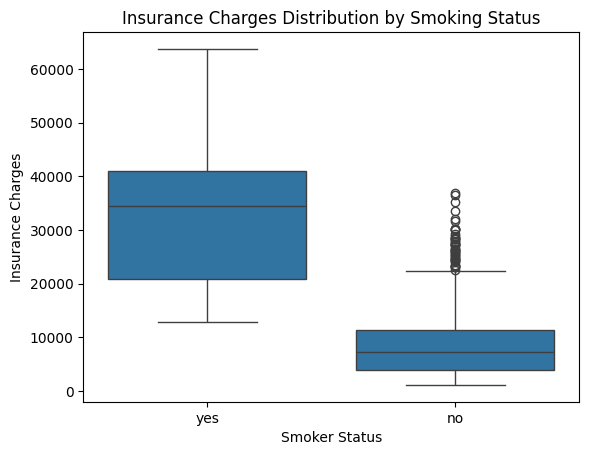

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="smoker", y="charges")

plt.title("Insurance Charges Distribution by Smoking Status")
plt.xlabel("Smoker Status")
plt.ylabel("Insurance Charges")

plt.show()

### Insight

The box plot shows that smokers generally have higher insurance charges and greater variation in costs than non-smokers. Several high-cost outliers are also present among smokers.

## Age vs Insurance Charges

This scatter plot examines the relationship between an individual's age and their medical insurance charges.

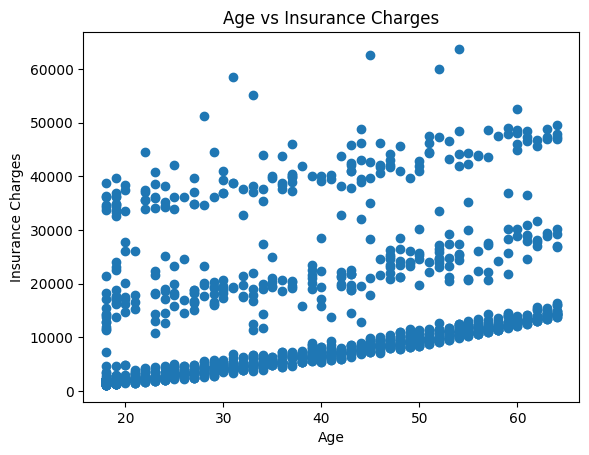

In [63]:
plt.scatter(df["age"], df["charges"])

plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")

plt.show()

### Insight

The scatter plot shows that insurance charges generally increase as age increases. However, the data points are widely spread, indicating that age alone does not fully explain differences in insurance costs.

## BMI vs Insurance Charges

This scatter plot examines the relationship between an individual's BMI and their medical insurance charges.

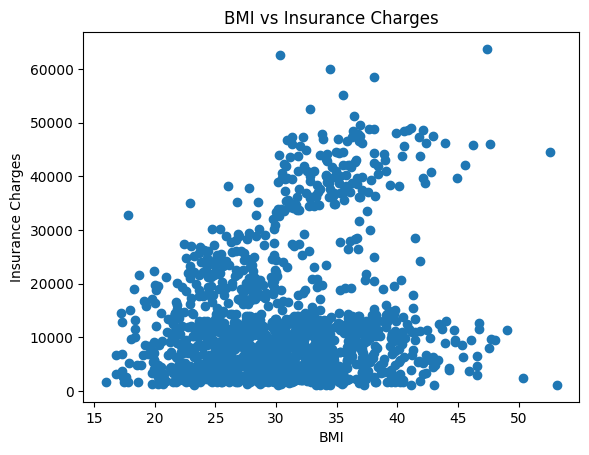

In [64]:
plt.scatter(df["bmi"], df["charges"])

plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")

plt.show()

### Insight

The scatter plot shows a slight positive relationship between BMI and insurance charges. However, the data points are widely distributed, suggesting that BMI alone is not a strong predictor of insurance costs.

## Age vs Insurance Charges by Smoking Status

This scatter plot examines the relationship between age and insurance charges while comparing differences between smokers and non-smokers.

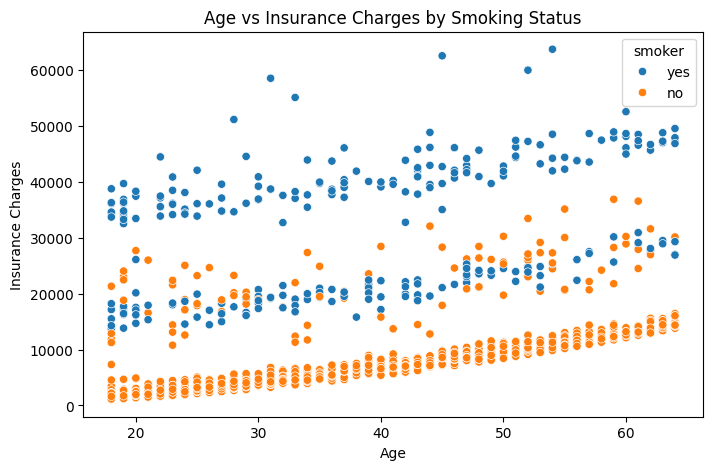

In [65]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="age",
    y="charges",
    hue="smoker"
)

plt.title("Age vs Insurance Charges by Smoking Status")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")

plt.show()

### Insight

The visualization shows that smokers generally have higher insurance charges across different age groups. While insurance costs tend to increase with age, smoking status creates a noticeable difference in overall charges.

## Regional Analysis

This analysis compares the average insurance charges across the different geographic regions in the dataset.

In [66]:
df.groupby("region")["charges"].mean()

,charges
region,
northeast,13406.384516
northwest,12417.575374
southeast,14735.411438
southwest,12346.937377


### Insight

The Southeast region has the highest average insurance charges compared to the other regions. The Northwest and Southwest regions show similar average costs, while the Northeast falls between these groups.

### Average Insurance Charges by Region

A bar chart was created to visualize the differences in average insurance charges across the four geographic regions.

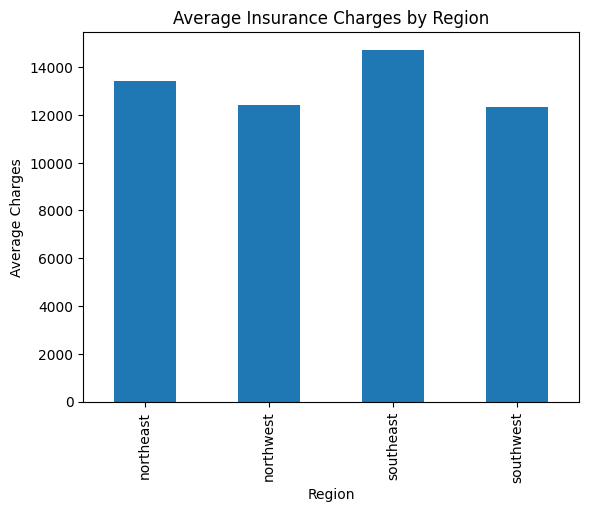

In [67]:
df.groupby("region")["charges"].mean().plot(kind="bar")

plt.title("Average Insurance Charges by Region")
plt.xlabel("Region")
plt.ylabel("Average Charges")

plt.show()

### Insight

The Southeast region has the highest average insurance charges compared to the other regions. The Northwest and Southwest regions have similar average costs, while the Northeast falls between the groups.

### BMI and Insurance Charges Correlation

A correlation calculation was performed to measure the relationship between BMI and insurance charges.

In [68]:
df["bmi"].corr(df["charges"])

np.float64(0.19834096883362895)

### Insight

The correlation value of approximately 0.20 indicates a weak positive relationship between BMI and insurance charges. This suggests that BMI may have some association with medical costs, but it is not a strong predictor by itself.

## BMI vs Insurance Charges by Smoking Status

This scatter plot examines the relationship between BMI and insurance charges while comparing differences between smokers and non-smokers.

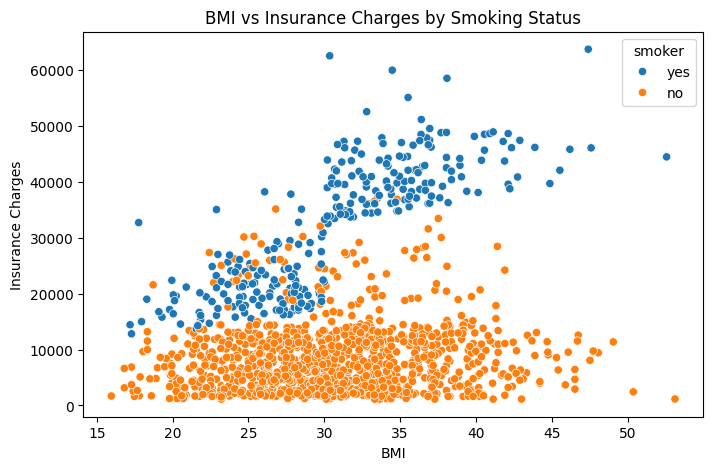

In [69]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="bmi",
    y="charges",
    hue="smoker"
)

plt.title("BMI vs Insurance Charges by Smoking Status")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")

plt.show()

### Insight

The visualization shows that smokers generally have higher insurance charges across different BMI levels. While BMI has some relationship with insurance costs, smoking status appears to have a stronger influence on overall charges.

In [70]:
df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [71]:
df.corr(numeric_only=True).to_string()

'               age       bmi  children   charges\nage       1.000000  0.109272  0.042469  0.299008\nbmi       0.109272  1.000000  0.012759  0.198341\nchildren  0.042469  0.012759  1.000000  0.067998\ncharges   0.299008  0.198341  0.067998  1.000000'

## Correlation Matrix Heatmap

A heatmap was created to visualize the strength and direction of relationships between numerical variables in the dataset.

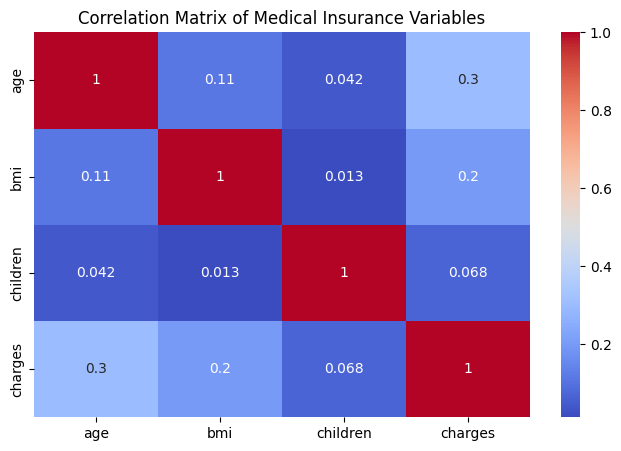

In [72]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Medical Insurance Variables")

plt.show()

### Insight

The heatmap shows that age has the strongest positive correlation with insurance charges compared to the other numerical variables. BMI has a weaker positive relationship, while the number of children has

## Region and Smoking Status Analysis

This analysis examines the combined relationship between geographic region, smoking status, and average insurance charges.

In [73]:
df.groupby(["region", "smoker"])["charges"].mean()

region     smoker
northeast  no         9165.531672
           yes       29673.536473
northwest  no         8556.463715
           yes       30192.003182
southeast  no         8032.216309
           yes       34844.996824
southwest  no         8019.284513
           yes       32269.063494
Name: charges, dtype: float64

### Insight

Across all regions, smokers have significantly higher average insurance charges compared to non-smokers. This suggests that smoking status has a stronger influence on insurance costs than geographic location.

# Final Conclusions

This project analyzed the Medical Cost Personal Dataset using exploratory data analysis (EDA) techniques to identify factors associated with medical insurance charges.

## Key Findings

- Smoking status had the strongest relationship with insurance charges, with smokers consistently incurring much higher costs than non-smokers.
- Insurance charges generally increased with age, indicating a positive relationship between age and medical costs.
- BMI showed a weak positive relationship with insurance charges, suggesting that it has some influence but is not the primary factor.
- Regional differences in average insurance charges existed, but they were much smaller than the differences associated with smoking status.
- The correlation analysis supported the visualizations, showing that age had the strongest positive correlation with insurance charges among the numerical variables.

## Conclusion

Overall, smoking status appears to be the most significant factor affecting medical insurance charges in this dataset. The analysis demonstrates how exploratory data analysis can be used to identify trends, compare groups, and gain insights from real-world healthcare data.